<a href="https://colab.research.google.com/github/PiyaliChoudhury/IMDB-Review-Sentiment-Analysis/blob/main/IMDB__Review_Sentiment_Analysis_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDb Review Sentiment Analysis

This notebook performs sentiment analysis on the IMDb movie reviews dataset.

Models included:
- Logistic Regression
- Naive Bayes
- LSTM Deep Learning

Evaluation metrics:
- Accuracy
- F1 Score
- Confusion Matrix
- Model comparison graphs


In [ ]:
# Install libraries
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow nltk

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import nltk
from nltk.corpus import stopwords
import re

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Loading Dataset

In [ ]:
# Upload dataset (IMDB Dataset.csv)
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip imdb-dataset.zip

unzip:  cannot find or open imdb-dataset.zip, imdb-dataset.zip.zip or imdb-dataset.zip.ZIP.


In [ ]:
!unzip imdb-dataset.zip -d imdb_data

unzip:  cannot find or open imdb-dataset.zip, imdb-dataset.zip.zip or imdb-dataset.zip.ZIP.


In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: IMDB Dataset.csv        


In [ ]:
!ls

 archive.zip  'IMDB Dataset.csv'   sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Data Preprocessing

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_review'] = df['review'].apply(clean_text)

df['sentiment'] = df['sentiment'].map({'positive':1,'negative':0})
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,1,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visually stunnin...


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = re.sub('<.*?>',' ',text)
    text = re.sub('[^a-zA-Z]',' ',text)

    text = text.lower()

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visually stunnin...


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = re.sub('<.*?>',' ',text)
    text = re.sub('[^a-zA-Z]',' ',text)

    text = text.lower()

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visually stunnin...


In [ ]:
from collections import Counter

all_words = " ".join(df['clean_review']).split()

word_counts = Counter(all_words)

rare_words = {word for word,count in word_counts.items() if count < 5}

def remove_rare(text):
    return " ".join([w for w in text.split() if w not in rare_words])

df['clean_review'] = df['clean_review'].apply(remove_rare)
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,mattei love time money visually stunning film ...


## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['sentiment'], test_size=0.2, random_state=42
)

## TF-IDF Feature Extraction

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
max_features=20000,
ngram_range=(1,2),
min_df=2,
max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print('Logistic Regression Accuracy:', lr_acc)
print('F1 Score:', lr_f1)
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8915
F1 Score: 0.8936170212765957
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
C=5,
max_iter=2000,
class_weight='balanced',
n_jobs=-1
)

lr.fit(X_train_tfidf,y_train)

LogisticRegression(C=5, class_weight='balanced', max_iter=2000, n_jobs=-1)

## Naive Bayes

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

nb_acc = accuracy_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print('Naive Bayes Accuracy:', nb_acc)
print('F1 Score:', nb_f1)
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8551
F1 Score: 0.8565488565488566
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4961
           1       0.85      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



## LSTM Deep Learning Model

In [ ]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=200)
X_test_pad = pad_sequences(X_test_seq, maxlen=200)

In [ ]:
print("Vocabulary Size:", len(tokenizer.word_index))

Vocabulary Size: 90703


In [ ]:
model = Sequential()

model.add(Embedding(5000, 128, input_length=200))
model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
negations = {"not","no","never","n't"}

stop_words = stop_words - negations

def clean_text(text):

    text = re.sub('<.*?>',' ',text)
    text = re.sub('[^a-zA-Z]',' ',text)

    text = text.lower()

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

df['sentiment'] = df['sentiment'].map({'positive':1,'negative':0})
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,NaN,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,NaN,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,NaN,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,NaN,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",NaN,petter mattei love time money visually stunnin...


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
df['clean_review'],
df['sentiment'],
test_size=0.2,
random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
max_features=20000,
ngram_range=(1,2),
min_df=2,
max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print(df['sentiment'].unique())

[nan]


In [ ]:
# Reload dataset first
df = pd.read_csv("IMDB Dataset.csv")

# Check original values
print(df['sentiment'].unique())

# Clean labels
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# Convert to numbers
df['sentiment'] = df['sentiment'].replace({
    'positive': 1,
    'negative': 0
})

# Verify
print(df['sentiment'].unique())

['positive' 'negative']
[1 0]


/tmp/ipykernel_18520/3803040889.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace({


In [ ]:
print(df['sentiment'].isna().sum())

0


In [ ]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df['sentiment'] = df['sentiment'].str.strip().str.lower()

df['sentiment'] = df['sentiment'].replace({
    'positive':1,
    'negative':0
})

print(df['sentiment'].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


/tmp/ipykernel_18520/3646757589.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace({


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = re.sub('<.*?>',' ',text)
    text = re.sub('[^a-zA-Z]',' ',text)

    text = text.lower()

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
print(df.columns)

Index(['review', 'sentiment', 'clean_review'], dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000,)
(10000,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(40000, 20000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

lr = LogisticRegression(
    C=5,
    max_iter=2000,
    n_jobs=-1
)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)
print("F1 Score:", lr_f1)

Logistic Regression Accuracy: 0.9007
F1 Score: 0.9024078624078624


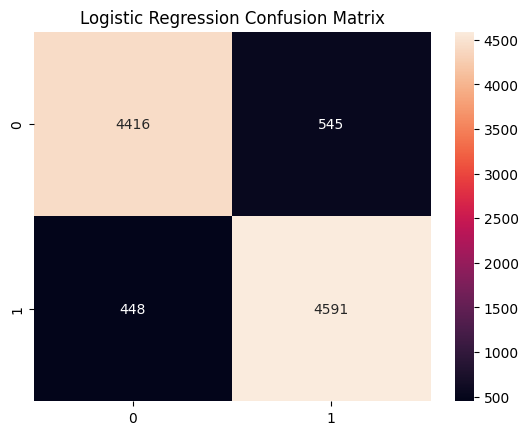

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
loss, lstm_acc = model.evaluate(X_test_pad, y_test)

print("LSTM Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.8795 - loss: 0.2911
LSTM Accuracy: 0.8794999718666077


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("===== Logistic Regression =====")

print("Accuracy:", lr_acc)
print("F1 Score:", lr_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

===== Logistic Regression =====
Accuracy: 0.9007
F1 Score: 0.9024078624078624

Confusion Matrix:
[[4416  545]
 [ 448 4591]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
print("===== Naive Bayes =====")

print("Accuracy:", nb_acc)
print("F1 Score:", nb_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

===== Naive Bayes =====
Accuracy: 0.8551
F1 Score: 0.8565488565488566

Confusion Matrix:
[[4225  736]
 [ 713 4326]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4961
           1       0.85      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [ ]:
y_pred_lstm = (model.predict(X_test_pad) > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step


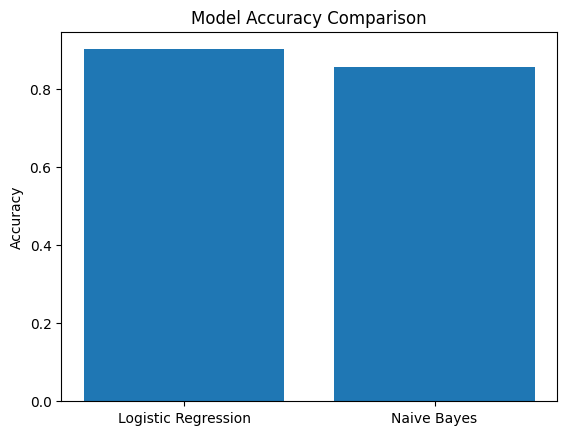

In [ ]:
models = ['Logistic Regression','Naive Bayes']
accuracy = [lr_acc, nb_acc]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

##model accuracy comparison

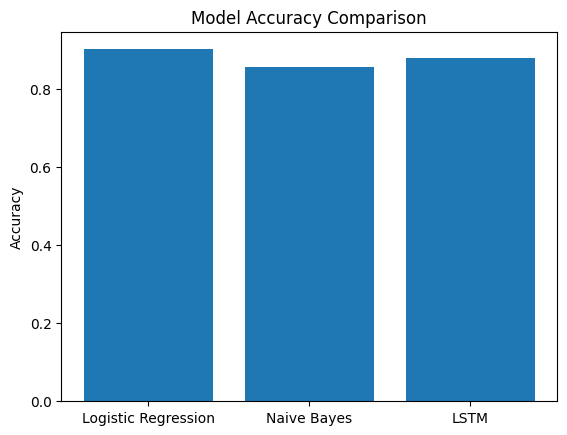

In [ ]:
models = ['Logistic Regression','Naive Bayes','LSTM']
accuracy = [lr_acc, nb_acc, lstm_acc]

plt.figure()

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({

"Model":["Logistic Regression","Naive Bayes","LSTM"],

"Accuracy":[lr_acc, nb_acc, lstm_acc],

"F1 Score":[lr_f1, nb_f1, lstm_acc]

})

print(results)

                 Model  Accuracy  F1 Score
0  Logistic Regression    0.9007  0.902408
1          Naive Bayes    0.8551  0.856549
2                 LSTM    0.8795  0.879500


##Logistic Regression Confusion matrix

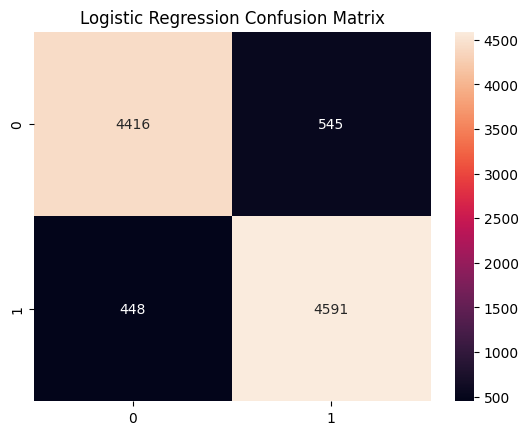

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Naive Bayes Confusion matrix

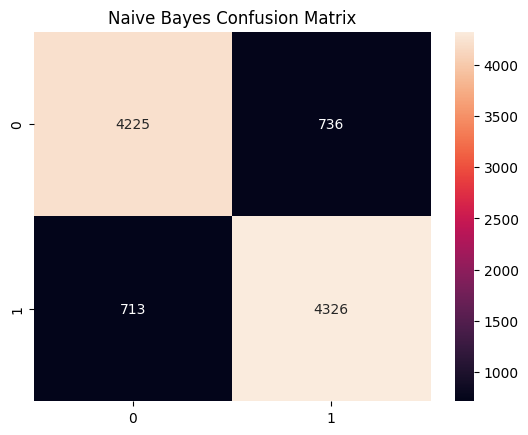

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

##LSTM Confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 131ms/step


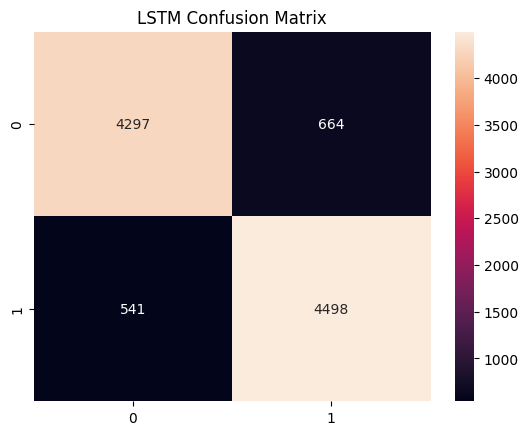

In [ ]:
y_pred_lstm = (model.predict(X_test_pad) > 0.5).astype("int32")

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

sns.heatmap(cm_lstm, annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")
plt.show()

##Model Accuracy comparison graph

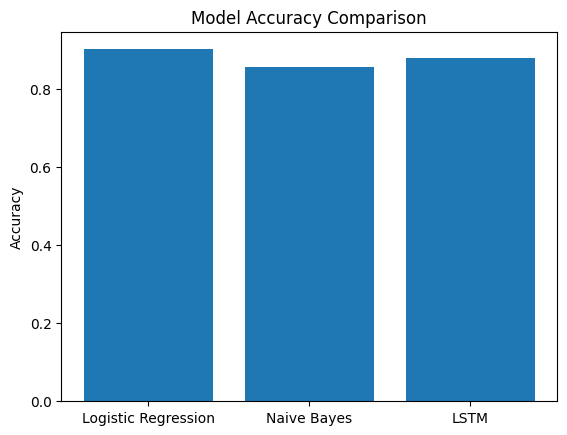

In [ ]:
models = ['Logistic Regression','Naive Bayes','LSTM']
accuracy = [lr_acc, nb_acc, lstm_acc]

plt.figure()

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

##F1 Score comparison graoh

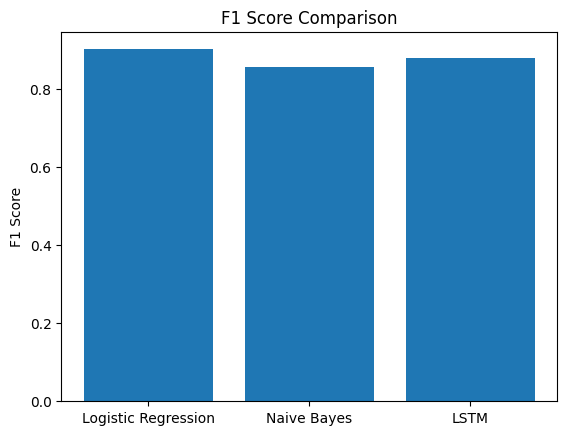

In [ ]:
f1_scores = [lr_f1, nb_f1, lstm_acc]

plt.figure()

plt.bar(models, f1_scores)

plt.title("F1 Score Comparison")

plt.ylabel("F1 Score")

plt.show()

## Epoch Training

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=6,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 251s 501ms/step - accuracy: 0.9116 - loss: 0.2283 - val_accuracy: 0.8666 - val_loss: 0.3156
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 301s 580ms/step - accuracy: 0.9288 - loss: 0.1860 - val_accuracy: 0.8661 - val_loss: 0.3476
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 230s 459ms/step - accuracy: 0.9448 - loss: 0.1517 - val_accuracy: 0.8686 - val_loss: 0.3771
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 256s 448ms/step - accuracy: 0.9531 - loss: 0.1285 - val_accuracy: 0.8627 - val_loss: 0.4030
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 223s 445ms/step - accuracy: 0.9580 - loss: 0.1145 - val_accuracy: 0.8619 - val_loss: 0.4346
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 229s 457ms/step - accuracy: 0.9722 - loss: 0.0838 - val_accuracy: 0.8524 - val_loss: 0.4949


##Plot Training Graph

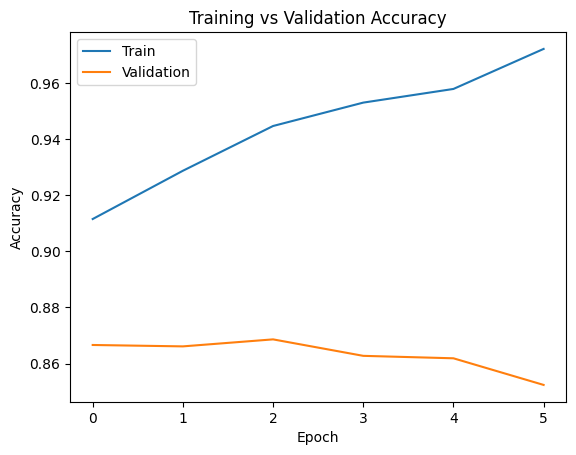

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

## Training Accuracy Graph

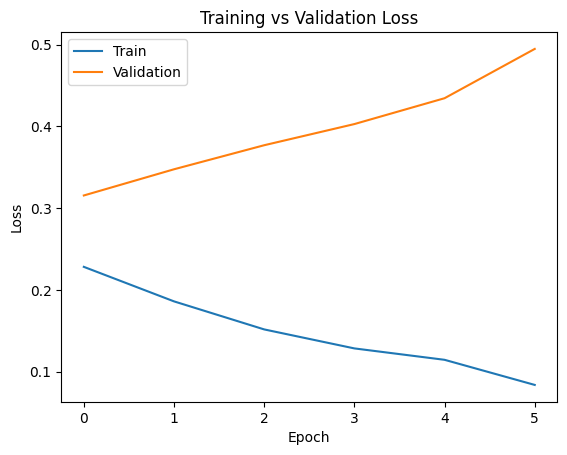

In [ ]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

##Saving model

In [ ]:
import joblib

joblib.dump(lr,"logistic_model.pkl")
joblib.dump(nb,"naive_bayes_model.pkl")

model.save("lstm_model.h5")